# Fine-Tuning TrOCR on the Bentham Historical Handwritten Manuscript Dataset

This notebook fine-tunes a pre-trained TrOCR model on the Bentham handwritten manuscript dataset and evaluates its performance using Character Error Rate (CER) and Word Error Rate (WER).

### Workflow

1. Load official Bentham partitions (test, train, and validation sets)
2. Create PyTorch dataset and dataloaders
3. Load pre-trained TrOCR
4. Fine-tune on training set
5. Evaluate on validation set
6. Evaluate on test set
7. Save best model

### Dataset

- Bentham Historical Manuscripts
- Line-level images
- Line-level ground truth transcriptions
- Official train/validation/test partitions

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import cv2
from PIL import Image
import random

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel
)

import editdistance
from jiwer import wer

from tqdm import tqdm

In [2]:
# freeze RSEED for reproducibility and comparability between CLAHE and original images
RSEED = 42

random.seed(RSEED)
np.random.seed(RSEED)
torch.manual_seed(RSEED)
torch.mps.manual_seed(RSEED)

In [3]:
# Root data folder

DATA_DIR = Path("data")

LINES_DIR = DATA_DIR / "BenthamDatasetR0-GT" / "Images" / "Lines"
TRANSCRIPTIONS_DIR = DATA_DIR / "BenthamDatasetR0-GT" / "Transcriptions"
PARTITIONS_DIR = DATA_DIR / "BenthamDatasetR0-GT" / "Partitions"

# Output folder

MODEL_DIR = Path("./saved_models")
MODEL_DIR.mkdir(exist_ok=True)


In [4]:
# accelerating training using Mac-specific GPU
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps" 
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: mps


In [5]:
# use the official split
def load_partition(file_path):

    with open(file_path, "r") as f:
        files = [line.strip() for line in f]

    return files

In [6]:
# load partitions files for train, validation, and test sets
train_ids = load_partition(
    PARTITIONS_DIR / "TrainLines.lst"
)

val_ids = load_partition(
    PARTITIONS_DIR / "ValidationLines.lst"
)

test_ids = load_partition(
    PARTITIONS_DIR / "TestLines.lst"
)

print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test:", len(test_ids))

Train: 9198
Validation: 1415
Test: 860


In [7]:
# Convert images and transcriptions into tensors, the readable format for the model
class BenthamDataset(Dataset):

    def __init__(
        self,
        sample_ids,
        image_dir,
        transcription_dir,
        processor
    ):

        self.sample_ids = sample_ids
        self.image_dir = image_dir
        self.transcription_dir = transcription_dir
        self.processor = processor

    def __len__(self):

        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]
        image_path = self.image_dir / f"{sample_id}.png"
        text_path  = self.transcription_dir / f"{sample_id}.txt"

        # Read as grayscale for CLAHE, then convert to RGB
        gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        # CLAHE: improves local contrast for faded/uneven historical ink
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)

        # Back to 3-channel RGB (TrOCR expects RGB)
        image = Image.fromarray(cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB))

        with open(text_path, "r", encoding="utf-8") as f:
            text = f.read().strip()

        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()
        labels = self.processor.tokenizer(text, return_tensors="pt").input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}


In [ ]:
from torchvision import transforms

train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=2, fill=255),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))
    ], p=0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

class BenthamTrainDataset(BenthamDataset):
    """BenthamDataset with augmentation applied to training images only."""

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]
        image_path = self.image_dir / f"{sample_id}.png"
        text_path  = self.transcription_dir / f"{sample_id}.txt"

        gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        image = Image.fromarray(cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB))

        image = train_augment(image)  # augmentation before processor

        with open(text_path, "r", encoding="utf-8") as f:
            text = f.read().strip()

        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()
        labels = self.processor.tokenizer(text, return_tensors="pt").input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}

In [9]:
# call the pre-trained TrOCR model
processor = TrOCRProcessor.from_pretrained(
    "microsoft/trocr-base-handwritten"
)

model = VisionEncoderDecoderModel.from_pretrained(
    "microsoft/trocr-base-handwritten"
)

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
# initializing the processor and the model
tokenizer = processor.tokenizer

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.pad_token_id = tokenizer.pad_token_id    

model.config.label_smoothing_factor = 0.1

model.to(device)

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=False)
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=False)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2):

In [11]:
# model parameters
BATCH_SIZE = 8
LEARNING_RATE = 1e-5
NUM_EPOCHS = 7
PATIENCE = 3

In [12]:
# Collator function
def collate_fn(batch):

    pixel_values = torch.stack(
        [item["pixel_values"] for item in batch]
    )

    labels = [item["labels"] for item in batch]

    labels = torch.nn.utils.rnn.pad_sequence(
        labels,
        batch_first=True,
        padding_value=tokenizer.pad_token_id
    )

    # ignore padding in loss
    labels[labels == tokenizer.pad_token_id] = -100

    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

In [13]:
train_dataset = BenthamTrainDataset(
    train_ids, 
    LINES_DIR, 
    TRANSCRIPTIONS_DIR, 
    processor
)

val_dataset = BenthamDataset(
    val_ids,
    LINES_DIR,
    TRANSCRIPTIONS_DIR,
    processor
)

test_dataset = BenthamDataset(
    test_ids,
    LINES_DIR,
    TRANSCRIPTIONS_DIR,
    processor
)

In [14]:
# create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [15]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

In [16]:
# scheduler (linear warmup)
from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(0.1 * total_steps)

# Create scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

In [17]:
# Evaluate the model according to CER/WER metrics
def cer(pred, gt):
    if len(gt) == 0:
        return 1.0
    return editdistance.eval(pred, gt) / len(gt)


def compute_wer(pred, gt):
    return wer(gt, pred)

In [18]:
# translate TrOCR output to text
def predict(pixel_values, num_beams=4):
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            num_beams=num_beams,
            early_stopping=True,
            max_new_tokens=128,      # cap to avoid runaway generation
            no_repeat_ngram_size=3,  # penalise repeated n-grams
        )
    return processor.batch_decode(generated_ids, skip_special_tokens=True)

In [19]:
# validation loop
def evaluate(loader):

    model.eval()

    total_cer = 0
    total_wer = 0
    count = 0

    with torch.no_grad():

        for batch in loader:

            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"]

            preds = predict(pixel_values)

            for i in range(len(preds)):

                pred = preds[i]

                gt_ids = labels[i].clone()

                # remove ignore tokens
                gt_ids[gt_ids == -100] = tokenizer.pad_token_id

                gt = tokenizer.decode(
                    gt_ids,
                    skip_special_tokens=True
                )

                total_cer += cer(pred, gt)
                total_wer += compute_wer(pred, gt)

                count += 1

    return total_cer / count, total_wer / count

In [20]:
# Early stopping setup
best_val_cer = float("inf")
early_stop_counter = 0

In [21]:
# Track training history

train_losses = []
val_cer_history = []
val_wer_history = []

In [22]:
# training loop with saving the best model 
for epoch in range(NUM_EPOCHS):

    model.train()

    total_loss = 0

    for batch in train_loader:

        pixel_values = batch["pixel_values"].to(device)

        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        scheduler.step()

        total_loss += loss.item()

    # Average training loss

    train_loss = total_loss / len(train_loader)

    # Validation metrics

    val_cer, val_wer = evaluate(val_loader)

    # Save history

    train_losses.append(train_loss)

    val_cer_history.append(val_cer)

    val_wer_history.append(val_wer)

    print("\n" + "=" * 50)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation CER: {val_cer:.4f}")

    print(f"Validation WER: {val_wer:.4f}")

    # Save best model

    if val_cer < best_val_cer:

        best_val_cer = val_cer

        early_stop_counter = 0

        model.save_pretrained("./best_trocr_new_model")

        processor.save_pretrained("./best_trocr_new_model")

        print(" Best model saved")

    else:

        early_stop_counter += 1

        print(
            f"No improvement ({early_stop_counter}/{PATIENCE})"
        )

        if early_stop_counter >= PATIENCE:

            print("Early stopping triggered")

            break


Epoch 1/7
Train Loss: 1.1288
Validation CER: 0.0686
Validation WER: 0.1363


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Best model saved

Epoch 2/7
Train Loss: 0.3521
Validation CER: 0.0587
Validation WER: 0.1195


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Best model saved

Epoch 3/7
Train Loss: 0.2258
Validation CER: 0.0508
Validation WER: 0.1126


...

 Best model saved

Epoch 5/7
Train Loss: 0.1034
Validation CER: 0.0509
Validation WER: 0.1047
No improvement (1/3)

Epoch 6/7
Train Loss: 0.0664
Validation CER: 0.0470
Validation WER: 0.0975


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Best model saved

Epoch 7/7
Train Loss: 0.0462
Validation CER: 0.0428
Validation WER: 0.0921


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Best model saved


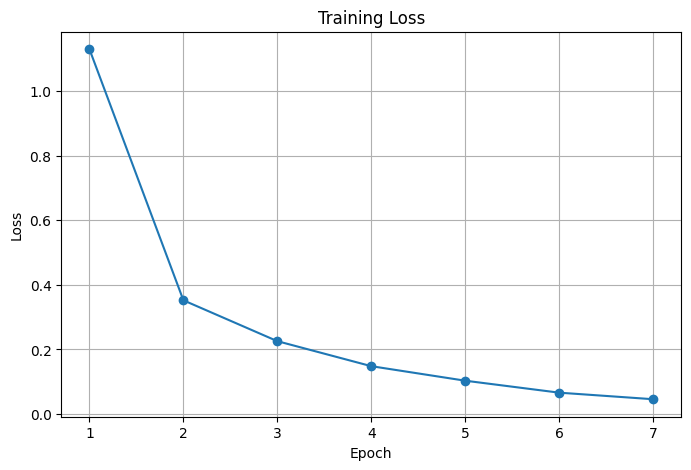

In [23]:
# Plot training loss across epochs
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

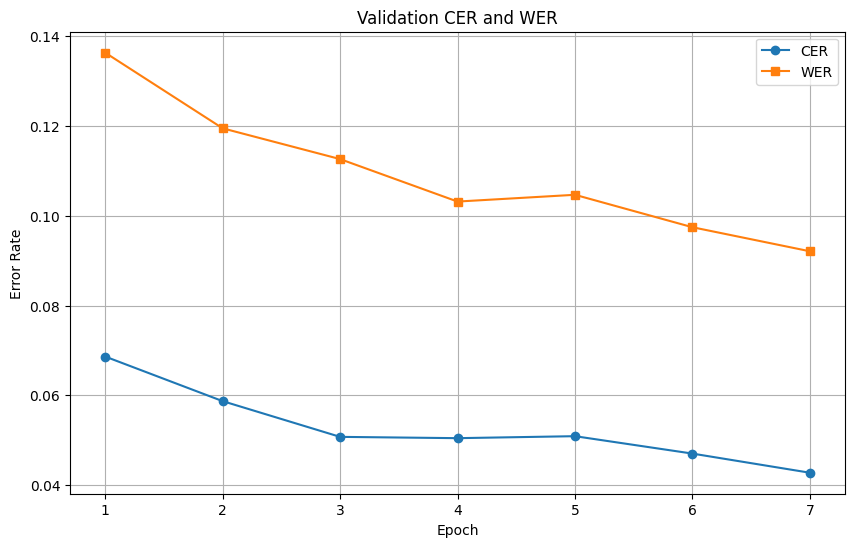

In [24]:
# Plot CER and WER across epochs
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(val_cer_history)+1),
    val_cer_history,
    marker="o",
    label="CER"
)

plt.plot(
    range(1, len(val_wer_history)+1),
    val_wer_history,
    marker="s",
    label="WER"
)

plt.xlabel("Epoch")
plt.ylabel("Error Rate")
plt.title("Validation CER and WER")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Save results to df
history_df = pd.DataFrame({
    "epoch": range(
        1,
        len(train_losses)+1
    ),
    "train_loss": train_losses,
    "val_cer": val_cer_history,
    "val_wer": val_wer_history
})

history_df

,epoch,train_loss,val_cer,val_wer
0,1,1.128836,0.068641,0.136343
1,2,0.352139,0.058712,0.119499
2,3,0.225755,0.050754,0.112642
3,4,0.148373,0.050465,0.103180
4,5,0.103446,0.050907,0.104689
5,6,0.066431,0.047029,0.097465
6,7,0.046153,0.042765,0.092108


In [26]:
# save it to .csv file
history_df.to_csv("training_history.csv", index=False)

In [27]:
# load the best model found
best_model = VisionEncoderDecoderModel.from_pretrained(
    "./best_trocr_new_model"
)

best_model.to(device)

model = best_model

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

In [28]:
# final test evaluation
test_cer, test_wer = evaluate(test_loader)

print("\n===== FINAL TEST RESULTS =====")

print(
    f"CER: {test_cer:.4f}"
)

print(
    f"WER: {test_wer:.4f}"
)


===== FINAL TEST RESULTS =====
CER: 0.0774
WER: 0.3768


Character-level error is acceptable, while word-level needs improvement. Let's see some examples of ground-truth vs predicted texts.

In [30]:
# Qualitative inspection: compare ground truth vs predictions on 10 test samples
model.eval()

samples_shown = 0

with torch.no_grad():

    for batch_idx, batch in enumerate(test_loader):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"]

        preds = predict(pixel_values)

        for i in range(len(preds)):

            if samples_shown >= 10:
                break

            pred = preds[i]

            gt_ids = labels[i].clone()
            gt_ids[gt_ids == -100] = tokenizer.pad_token_id
            ground_truth = tokenizer.decode(gt_ids, skip_special_tokens=True)

            print(f"Sample {samples_shown + 1}")
            print(f"  GT : {ground_truth}")
            print(f"  PR : {pred}")
            print(f"  CER: {cer(pred, ground_truth):.4f}")
            print()

            samples_shown += 1

        if samples_shown >= 10:
            break

Sample 1
  GT : brain.
  PR : brain .
  CER: 0.1667

Sample 2
  GT : From this review then it appears, that
  PR : From this review then it appears , that
  CER: 0.0263

Sample 3
  GT : in paving the way to the consideration of
  PR : in paving the way to the confederation of
  CER: 0.0488

Sample 4
  GT : municipal Law, our Author has spent
  PR : unmingham , our Author has sent
  CER: 0.2857

Sample 5
  GT : supposed
  PR : supposed
  CER: 0.0000

Sample 6
  GT : much time in explaining the nature &
  PR : must time in explaining the nature or
  CER: 0.1111

Sample 7
  GT : Properties of Laws which do not exist &
  PR : Ownerlies of Laws which do not exist :   <gap/>
  CER: 0.3846

Sample 8
  GT : in misapplying those which do: & therefore,
  PR : in missoplying those which do :  to therefore ,
  CER: 0.1628

Sample 9
  GT : that the best thing which a Student of the
  PR : pat the best thing whilst a Student of the
  CER: 0.1190

Sample 10
  GT : Law can do is to forget all that our

In historical manuscript datasets, <gap/> generally means:

There is missing, unreadable, damaged, obscured, or unavailable text at this position.